In [1]:
import sys
sys.path.append("../../src")
from common_imports import *
from kibble_zurek import state
from kibble_zurek import sigma_general as sigmax
from kibble_zurek import P_n as Px
from time_evolved_z_correlators import sigma_general as sigmaz
from time_evolved_z_correlators import P_n as Pz
from joblib import Parallel, delayed
import numpy as np
import kibble_zurek as kz
from itertools import combinations
from collections import Counter
import adprox

In [228]:
taus = np.logspace(-2,3,300)
from joblib import Parallel, delayed

states = Parallel(n_jobs=-1, backend="loky")(
    delayed(kz.state)(512, tau, tau) for tau in taus
)


(np.float64(0.01), np.float64(1000.0))

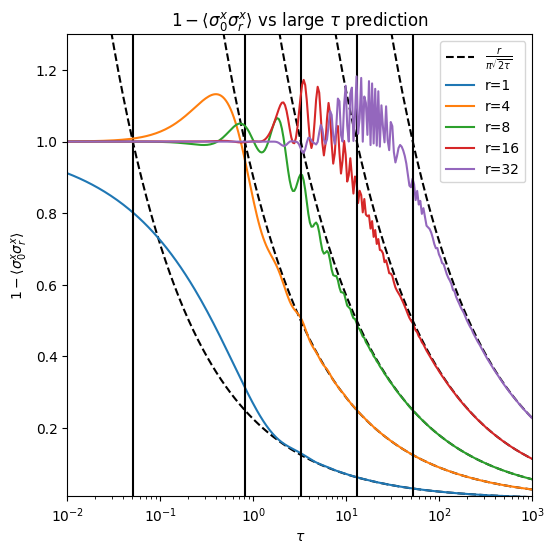

In [239]:
rs = [1,4,8,16,32]
plt.figure(figsize=(6,6))
title(r"$1-\langle \sigma^x_0 \sigma^x_r \rangle$ vs large $\tau$ prediction")
for r in rs:
    if r==1:
        plot(taus,1-(1-r/pi/sqrt(2*taus)),"--k",label=r"$\frac{r}{\pi \sqrt{2\tau}}$")
    else:
        plot(taus,1-(1-r/pi/sqrt(2*taus)),"--k")
    xx_dat_tau = array([sigmax([0,r],s) for s in states])
    plot(taus,(1-xx_dat_tau),label=f"r={r}")
    plt.vlines(r*r/2/pi/pi,0,2,"black")

ylabel(r"$1-\langle \sigma^x_0 \sigma^x_r \rangle$")
xlabel(r"$\tau$")
legend()
xscale("log")
#yscale("log")
ylim(0.01,1.3)
xlim(taus[0],taus[-1])
#plt.savefig("figures/xx_correlators_r_large_tau.png")

(0.1, 31.622776601683793)

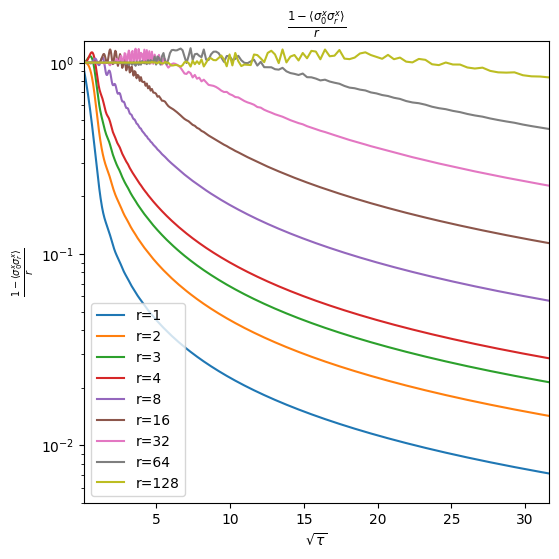

In [273]:
from joblib import Parallel, delayed
import numpy as np

rs = [1,2,3,4,8,16,32,64,128]
plt.figure(figsize=(6,6))
title(r"$\frac{1-\langle \sigma^x_0 \sigma^x_r \rangle}{r}$")

for r in rs:
    xx_dat_tau = np.array(
        Parallel(n_jobs=-1, backend="loky")(
            delayed(sigmax)([0, r], s) for s in states
        )
    )
    plot(sqrt(taus), (1 - xx_dat_tau) , label=f"r={r}")

ylabel(r"$\frac{1-\langle \sigma^x_0 \sigma^x_r \rangle}{r}$")
xlabel(r"$\sqrt{\tau}$")
legend()
#xscale("log")
yscale("log")
ylim(0.005, 1.3)
xlim(sqrt(taus[0]), sqrt(taus[-1]))


In [ ]:
P0 = array([array([adprox.P_n(n,tau) for tau in tqdm(taus)]) for n in ns])

100%|██████████| 2000/2000 [00:00<00:00, 150988.30it/s]


100%|██████████| 2000/2000 [01:21<00:00, 24.65it/s]


100%|██████████| 300/300 [00:00<00:00, 25433.90it/s]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31992/1428792299.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31992/1428792299.py:24: RuntimeWarning: invalid value encountered in power
  term1 = 1/8/taus/log(taus)**(3/2)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31992/1428792299.py:26: RuntimeWarning: invalid value encountered in sqrt
  term3= -pi/128/taus/taus/sqrt(log(taus)**7)


[]

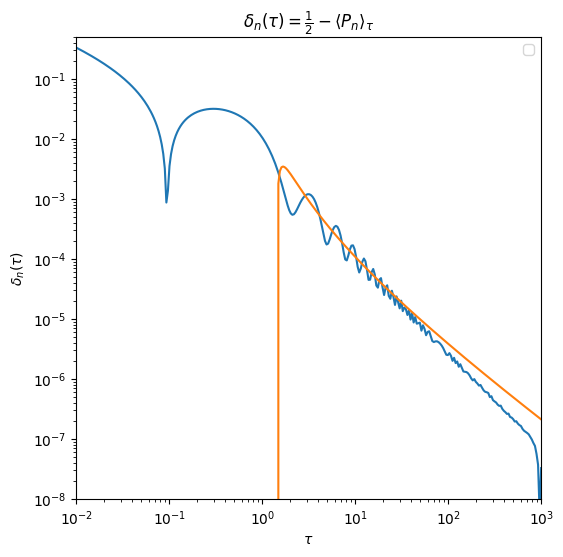

In [158]:
ns = [2]
plt.figure(figsize=(6,6))
title(r"$\delta_n(\tau)=\frac{1}{2}-\langle P_n \rangle _\tau$")
for n in ns:
   test = (n-1)/4/pi/sqrt(2*taus)
   # if n==2:
   #    #pass
   #plot(taus,test,"--k",label=r"$\frac{n-1}{4\pi \sqrt{2\tau}}$")
   # else:
   #     #pass
   #      plot(taus,test,"--k")
   delta_n_tau = abs(array([1/2-Px(n,s) for s in tqdm(states)]))
   
   #plot(taus,delta_n_tau,label=f"n={n}")
   plot(taus,abs(delta_n_tau-test))

   # plt.vlines((n-1)*(n-1)/2/pi/pi,0,2,"black")

ylabel(r"$\delta_n(\tau)$")
xlabel(r"$\tau$")
legend()
xscale("log")
#yscale("log")
term1 = 1/8/taus/log(taus)**(3/2)
term2=-1/32/sqrt(2)/pi/pi/sqrt(taus**3)
term3= -pi/128/taus/taus/sqrt(log(taus)**7)
plot(taus,(term1+term2+term3)/32)
#plot(taus, 1/8 * (1/taus)/(log(taus))**(3/2)*(exp(-pi/(4*log(taus)*log(taus)*taus))))
ylim(0.00000001,0.5)
xlim(taus[0],taus[-1])
#plt.savefig("figures/Pn_defect_large_tau.png")
#yscale("log")
loglog()

  5%|▍         | 14/300 [00:00<00:02, 111.85it/s]

KeyboardInterrupt: 

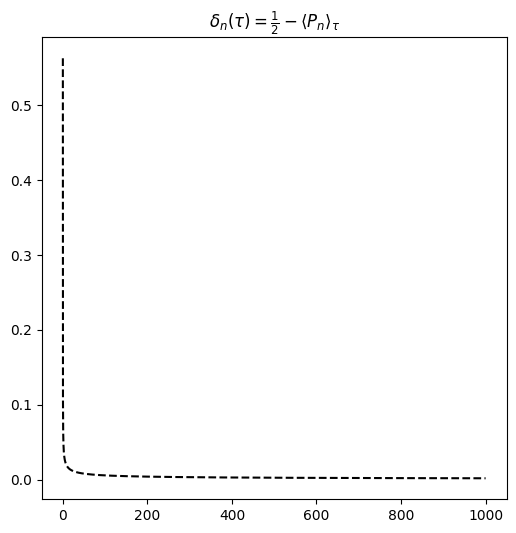

In [74]:
from joblib import Parallel, delayed
from tqdm import tqdm
import numpy as np

def delta_n_for_state(n, s):
    return 0.5 - Px(n, s)

ns = [2,6,8,12]
plt.figure(figsize=(6,6))
title(r"$\delta_n(\tau)=\frac{1}{2}-\langle P_n \rangle _\tau$")

for n in ns:
    test = (n-1)/4/pi/np.sqrt(2*taus)
    if n == 2:
        plot(taus, test, "--k", label=r"$\frac{n-1}{4\pi \sqrt{2\tau}}$")
    else:
        plot(taus, test, "--k")

    delta_n_tau = np.array(
        Parallel(n_jobs=-1)(
            delayed(delta_n_for_state)(n, s)
            for s in tqdm(states)
        )
    )

    plot(taus, delta_n_tau, label=f"n={n}")

ylabel(r"$\delta_n(\tau)$")
xlabel(r"$\tau$")
legend()
xscale("log")
yscale("log")
xlim(taus[0], taus[-1])


In [162]:
taus2 = np.linspace(0.1,30,50)
states2 = [kz.state(256,tau,tau) for tau in tqdm(taus2)]


























































































































































100%|██████████| 50/50 [00:21<00:00,  2.37it/s]


2



100%|██████████| 300/300 [00:00<00:00, 22381.16it/s]
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


3



100%|██████████| 300/300 [00:00<00:00, 7992.35it/s]


4


...




100%|██████████| 300/300 [00:00<00:00, 1326.17it/s]


6








100%|██████████| 300/300 [00:00<00:00, 496.92it/s]


10

























































































































































100%|██████████| 300/300 [00:22<00:00, 13.25it/s]


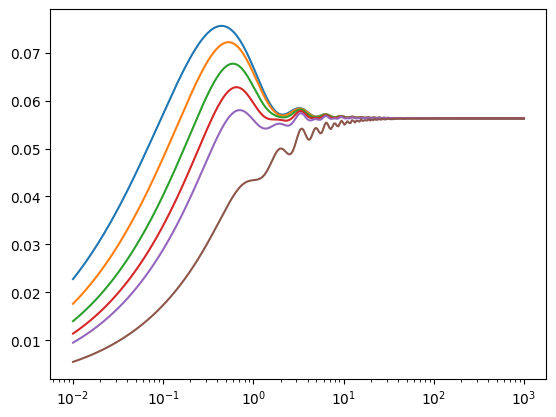

In [ ]:
ns = [2,3,4,5,6,7,8,9,10,11,12]
for n in ns:
    print(n)
    x = array([1/2-Px(n,s2) for s2 in tqdm(states)])
    plot(taus,sqrt(taus)*x/(n-1),label=f"n={n}")
xscale("log")
xlabel(r"$\tau$")
ylabel(r"$\frac{\sqrt{taus}}{n-1}\delta_n(\tau)$")

2
3
4
5
6
7
8
9
10
11
12


(np.float64(0.01), np.float64(1000.0))

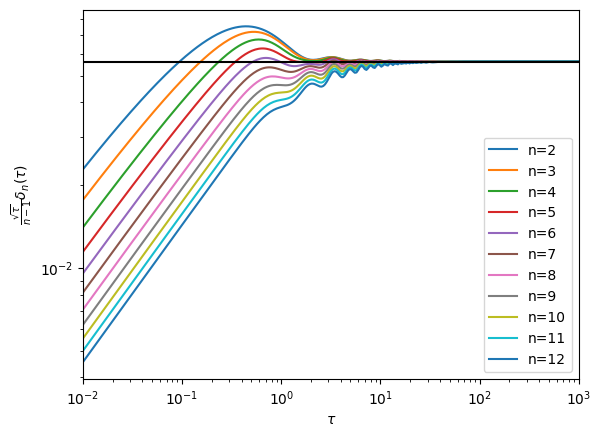

In [204]:
from joblib import Parallel, delayed

ns = [2,3,4,5,6,7,8,9,10,11,12]

def compute_x(n, states):
    return array([0.5 - Px(n, s2) for s2 in states])

for n in ns:
    print(n)
    x = array(
        Parallel(n_jobs=-1, backend="loky")(
            delayed(Px)(n, s2) for s2 in states
        )
    )
    x = 0.5 - x
    plot(taus, sqrt(taus) * x / (n - 1), label=f"n={n}")

xscale("log")
xlabel(r"$\tau$")
ylabel(r"$\frac{\sqrt{\tau}}{n-1}\delta_n(\tau)$")
legend()
plt.hlines(1/pi/sqrt(2)/4,taus[0],taus[-1],"black")
yscale("log")
xlim(taus[0],taus[-1])

2
3
4
5
6
7
8
9
10
11
12


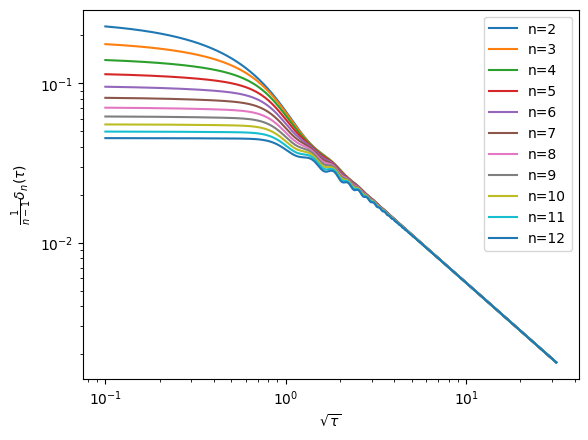

In [218]:
from joblib import Parallel, delayed

ns = [2,3,4,5,6,7,8,9,10,11,12]
def compute_x(n, states):
    return array([0.5 - Px(n, s2) for s2 in states])

for n in ns:
    print(n)
    x = array(
        Parallel(n_jobs=-1, backend="loky")(
            delayed(Px)(n, s2) for s2 in states
        )
    )
    x = 0.5 - x
    plot(sqrt(taus), x / (n - 1), label=f"n={n}")

xscale("log")
xlabel(r"$\sqrt{\tau}$")
ylabel(r"$\frac{1}{n-1}\delta_n(\tau)$")
legend()
yscale("log")


2
3
4
5
6
7
8
9
12


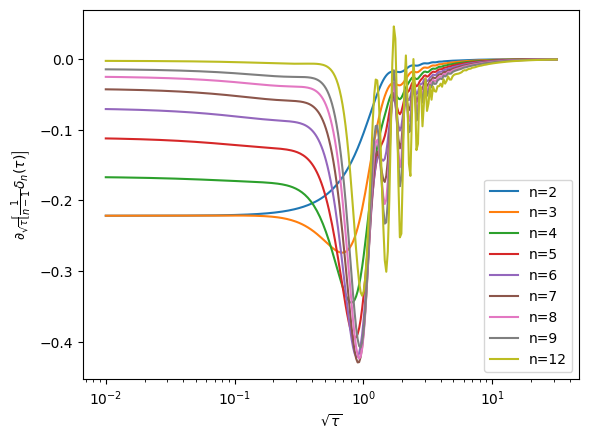

In [227]:
from joblib import Parallel, delayed
import numpy as np

ns = [2,3,4,5,6,7,8,9,12]

sqrt_taus = np.sqrt(taus)

for n in ns:
    print(n)
    x = np.array(
        Parallel(n_jobs=-1, backend="loky")(
            delayed(Px)(n, s2) for s2 in states
        )
    )
    y = (0.5 - x)

    dy_dsqrt = np.gradient(y, sqrt_taus)

    plot(sqrt_taus, dy_dsqrt, label=f"n={n}")

xscale("log")
#yscale("log")
xlabel(r"$\sqrt{\tau}$")
ylabel(r"$\partial_{\sqrt{\tau}}\!\left[\frac{1}{n-1}\delta_n(\tau)\right]$")
legend()
